# A/B Testing

***Problem Statement:***

Problem from an international online store. An A/B test has been launched. Technical specifications and test results are available.

***Technical Task:***

• Test Name: recommender_system_test;

• Groups: A (control), B (new payment funnel);

• Launch Date: 2020-12-07

• New User Recruitment Cutoff Date: 2020-12-21;

• Cutoff Date: 2021-01-04

• Audience: 15% of new users from the EU region;

• Test Purpose: To test changes related to the implementation of an improved recommendation system;

• Expected Impact: Within 14 days of registering in the system, users will show improved conversion rates for product page views (product_page event), shopping cart views (product_card event), and purchases. At each step of the funnel (product_page → product_card → purchase), the improvement will be at least 10%;

• Expected number of test participants: 6 000.

***It Is Necessary To:***
1. Conduct exploratory data analysis
2. Evaluate A/B testing results
3. Draw conclusions based on the results

## Contents
* [Step 1. Explore the Data](#1-bullet)
* [Step 2. Conduct Exploratory Data Analysis](#2-bullet)
* 2.1. [Examine Conversion Rates in the Funnel at Different Stages](#2-1-bullet)
* 2.2. [Do the Samples Have Identical Distributions of the Number of Events per User](#2-2-bullet)
* 2.3. [Are the Same Users in the Samples](#2-3-bullet)
* 2.4. [How the Number of Events is Distributed by Day](#2-4-bullet)
* 2.5. [Data Nuances to Consider Before Starting A/B Testing](#2-5-bullet)
* 2.6. [Users from Two Experimental Groups in the Recommender_System_Test](#2-6-bullet)
* [Step 3. Evaluate the A/B Testing Results](#3-bullet)
* [Step 4. Conclusions from the Exploratory Data Analysis Stage and the Evaluation of the A/B Testing Results](#4-bullet)

### Step 1. Explore the Data<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_marketing_events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_project_marketing_events.csv')

In [3]:
project_marketing_events.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


**Structure of the ab_project_marketing_events.csv file:**
- name — Name of the Marketing Event;
- regions — Regions in Which the Advertising Campaign Will Be Conducted;
- start_dt — Campaign Start Date;
- finish_dt — Campaign End Date

In [4]:
project_marketing_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


* The table has 14 rows and 4 columns.
* There are no missing values.
* The data type in the start_dt and finish_dt columns must be changed, converting string values ​​to dates.

In [5]:
project_marketing_events['start_dt'] = pd.to_datetime(project_marketing_events['start_dt'], format='%Y-%m-%d')

In [6]:
project_marketing_events['finish_dt'] = pd.to_datetime(project_marketing_events['finish_dt'], format='%Y-%m-%d')

In [7]:
project_marketing_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 576.0+ bytes


**Check for duplicates**

In [8]:
project_marketing_events['name'].value_counts()

St. Valentine's Day Giveaway        1
Christmas&New Year Promo            1
Chinese Moon Festival               1
Chinese New Year Promo              1
St. Patric's Day Promo              1
Victory Day CIS (May 9th) Event     1
CIS New Year Gift Lottery           1
International Women's Day Promo     1
Dragon Boat Festival Giveaway       1
Easter Promo                        1
Labor day (May 1st) Ads Campaign    1
Single's Day Gift Promo             1
Black Friday Ads Campaign           1
4th of July Promo                   1
Name: name, dtype: int64

    There are no duplicates in column ['name'].

In [9]:
project_marketing_events['regions'].value_counts()

APAC                        4
EU, CIS, APAC, N.America    3
CIS                         2
EU, CIS, APAC               2
EU, N.America               2
N.America                   1
Name: regions, dtype: int64

    There are no duplicates in the ['regions'] column

In [10]:
project_marketing_events.duplicated().sum()

0

    There are no duplicates in the project_marketing_events dataset.

In [11]:
ab_new_users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv')

In [12]:
ab_new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


**The structure of the final_ab_new_users.csv file:**
- user_id — Unique User Identifier;
- first_date — Registration Date;
- region — the User's Region;
- device — the Device Used for Registration.

In [13]:
ab_new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


* The table has 61 733 rows and 4 columns.
* There are no missing values.
* The "first_date" column needs to have its data type changed, converting string values ​​to dates.

In [14]:
ab_new_users['first_date'] = pd.to_datetime(ab_new_users['first_date'], format='%Y-%m-%d')

In [15]:
ab_new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     61733 non-null  object        
 1   first_date  61733 non-null  datetime64[ns]
 2   region      61733 non-null  object        
 3   device      61733 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.9+ MB


**Checking the ab_new_users dataset for duplicates**

In [16]:
ab_new_users.duplicated().sum()

0

    We're checking the ['region'] and ['device'] columns for duplicates.

    We're interested in users from the EU region.

In [17]:
ab_new_users['region'].value_counts()

EU           46270
N.America     9155
CIS           3155
APAC          3153
Name: region, dtype: int64

In [18]:
ab_new_users['device'].value_counts()

Android    27520
PC         15599
iPhone     12530
Mac         6084
Name: device, dtype: int64

    There are no duplicates in the ['region'] and ['device'] columns

In [19]:
final_ab_participants = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_participants.csv')

In [20]:
final_ab_participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,482F14783456D21B,B,recommender_system_test


**File structure of final_ab_participants.csv:**
- user_id — Unique User ID;
- ab_test — Test Name;
- group — the Group the User Was In During the Test

In [21]:
final_ab_participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB


* The table has 18 268 rows and 3 columns.
* There are no missing values.
* The data types are correct.

**Checking the final_ab_participants dataset for duplicates**

In [22]:
final_ab_participants.duplicated().sum()

0

There are no duplicates in the final_ab_participants dataset.

In [23]:
final_ab_participants['group'].value_counts()

A    9655
B    8613
Name: group, dtype: int64

In [24]:
final_ab_participants['ab_test'].value_counts()

interface_eu_test          11567
recommender_system_test     6701
Name: ab_test, dtype: int64

    There are no duplicates in the ['group'] and ['ab_test'] columns.
    Groups: A (control), B (new payment funnel)
    We are only interested in the test - recommender_system_test

In [25]:
final_ab_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv')

In [26]:
final_ab_events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


**The structure of the final_ab_events.csv file:**
- user_id — Unique User Identifier;
- event_dt — Date and Time of Purchase;
- event_name — Event Type Name;
- details — Additional Event Data. For Example, This Field Stores the Purchase Price (USD) for the "Purchase" Event.

In [27]:
final_ab_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB


* The table has 440 317 rows and 4 columns.
* Missing values ​​in the ['details'] column. We'll leave them unchanged, as the purchase price can only be in the "purchase" column.
* In the ['event_dt'] column, the data type must be changed, converting string values ​​to dates.

In [28]:
final_ab_events['event_dt'] = pd.to_datetime(final_ab_events['event_dt'], format='%Y-%m-%dT%H:%M:%S')

In [29]:
final_ab_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     440317 non-null  object        
 1   event_dt    440317 non-null  datetime64[ns]
 2   event_name  440317 non-null  object        
 3   details     62740 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 13.4+ MB


**Checking the final_ab_events dataset for duplicates**

In [30]:
final_ab_events['event_name'].value_counts()

login           189552
product_page    125563
purchase         62740
product_cart     62462
Name: event_name, dtype: int64

    There are no duplicates in column ['event_name']

In [31]:
final_ab_events.duplicated().sum()

0

    There are no duplicates in the final_ab_events dataset.

### Step 2. Conduct Exploratory Data Analysis<a class="anchor" id="2-bullet"></a>

**2.1. Examine Conversion Rates in the Funnel at Different Stages**<a class="anchor" id="2-1-bullet"></a>

    Let's look at what events are in the dataset and how often they occur.
    Let's sort the events by frequency.

In [32]:
events_count = final_ab_events.groupby('event_name').agg({'user_id':'count'}).reset_index().sort_values(by='user_id', ascending=False)
events_count.rename(columns={'user_id': 'quantity_events'}, inplace=True)
events_count

,event_name,quantity_events
0,login,189552
2,product_page,125563
3,purchase,62740
1,product_cart,62462


A total of 4 events, sorted by frequency:

* login - user registration
* product_page - product page visit
* purchase - order
* product_cart - adding product to cart

Somehow, some users place an order without going through the "adding order to cart" step. This step has fewer transactions than the "order" step.

**We'll build a funnel of unique users who complete events**

In [33]:
funnel_of_events = final_ab_events.groupby('event_name').agg({'user_id':'nunique'}).reset_index().sort_values(by='user_id', ascending=False)
funnel_of_events.rename(columns={'user_id': 'quantity_events'}, inplace=True)
funnel_of_events

,event_name,quantity_events
0,login,58697
2,product_page,38929
3,purchase,19569
1,product_cart,19284


 Using the event funnel, we calculate what proportion of users progress to the next step of the funnel (relative to the number of users in the previous step). That is, for the sequence of events
A → B → C → D, calculate the ratio of the number of users with event B to the number
of users with event A.

In [34]:
conversion_step2 = round(38929/58697*100)
conversion_step3 = round(19569/38929*100)
conversion_step4 = round(19284/19569*100)

In [35]:
print('% of users who moved to the second stage: {}'.format(conversion_step2))
print('% of users who moved to the third stage: {}'.format(conversion_step3))
print('% of users who moved to the fourth stage: {}'.format(conversion_step4))

% of users who moved to the second stage: 66
% of users who moved to the third stage: 50
% of users who moved to the fourth stage: 99


    The largest number of users are lost at the third stage.
    Only 50% of users make a purchase after viewing a product page.

    At the second stage, 36% of users are lost.
    After registration, 66% of users view product pages.

    The conversion rate between adding a product to cart and placing an order is 99%.

    Again, the data that more users completed an order than added a product to cart looks suspicious. Some users skipped this stage.

**2.2. Do the Samples Have Identical Distributions of the Number of Events per User**<a class="anchor" id="2-2-bullet"></a>

**How ​​many events are there in the dataset?**

In [36]:
events = len(final_ab_events)
print('Total events in the log: {}'.format(events), 'pc.')

Total events in the log: 440317 pc.


**How ​​many users are there in the dataset?**

In [37]:
users = final_ab_events['user_id'].nunique()
print('Total unique users in the log: {}'.format(users))

Total unique users in the log: 58703


**How ​​many events per user on average?**

    To determine the average number of events per user, we find measures of central tendency: 
    mean, median, and mode.

In [38]:
mean = final_ab_events.groupby('user_id')['event_name'].count().mean().round()
print('On average, there are events per user: {}'.format(mean))

On average, there are events per user: 8.0


In [39]:
median = final_ab_events.groupby('user_id')['event_name'].count().median().round()
print('On average, there are events per user: {}'.format(median))

On average, there are events per user: 6.0


In [40]:
mode = final_ab_events.groupby('user_id')['event_name'].count().mode()
print('On average, there are events per user: {}'.format(mode))

On average, there are events per user: 0    6
dtype: int64


    On average, there are six events per user. The median and mode values ​​are the same.

    Let's look at the distribution of events per user:

In [41]:
final_ab_events.groupby('user_id')['event_name'].count().describe()

count    58703.000000
mean         7.500758
std          4.230392
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         36.000000
Name: event_name, dtype: float64

In [42]:
events_per_user = final_ab_events.groupby('user_id')['event_name'].count().reset_index()

<AxesSubplot:>

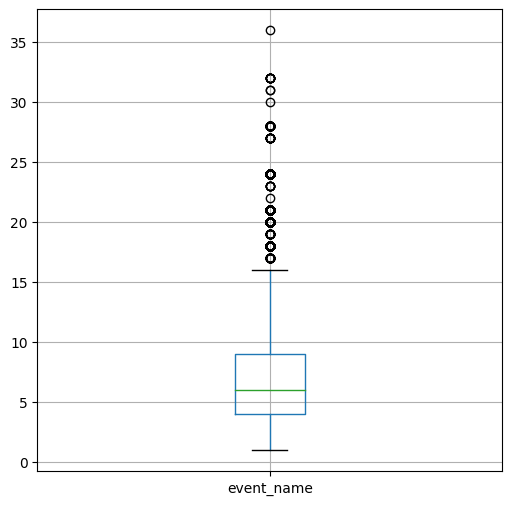

In [43]:
events_per_user.boxplot(column='event_name', figsize=(6,6))

* 25% of users report 4 events.

* 50% of users report up to 6 events.

* 75% of users report up to 9 events.

* Outliers start at 16 to 36 events per user.
The maximum outlier is 36 events per user.

**2.3. Are the Same Users in the Samples**<a class="anchor" id="2-3-bullet"></a>

In [44]:
final_ab_participants['user_id'].count()
print('Number of users in samples: {}'.format(events), 'people')

Number of users in samples: 440317 people


In [45]:
final_ab_participants['user_id'].nunique()
print('Number of unique users in samples: {}'.format(events), 'people')

Number of unique users in samples: 440317 people


In [46]:
final_ab_participants.groupby('user_id')['group'].nunique().describe()

count    16666.000000
mean         1.046562
std          0.210705
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: group, dtype: float64

    We see that the same users can be in different samples (both in group A and group B).
    The maximum value is when a user is included in both samples. Let's look at five random such users.

In [47]:
user_in_2_groups = final_ab_participants.groupby('user_id').agg({'group':'nunique'})
user_in_2_groups = user_in_2_groups[user_in_2_groups['group'] == 2]
user_in_2_groups

,group
user_id,
0082295A41A867B5,2
00E68F103C66C1F7,2
02313B9E82255F47,2
023D4A062F40F10B,2
040F6DD6E792D0AB,2
...,...
FEA0C585A53E7027,2
FEC0BCA6C323872F,2
FEE7040D7D2F2968,2


In [48]:
users_in_2_groups = ['0082295A41A867B5', '00E68F103C66C1F7', '02313B9E82255F47', '023D4A062F40F10B', '040F6DD6E792D0AB']

In [49]:
final_ab_participants.query('user_id in @users_in_2_groups').groupby('user_id').head(10)


,user_id,group,ab_test
585,02313B9E82255F47,A,recommender_system_test
869,023D4A062F40F10B,B,recommender_system_test
1278,040F6DD6E792D0AB,A,recommender_system_test
4074,00E68F103C66C1F7,A,recommender_system_test
4768,0082295A41A867B5,A,recommender_system_test
13448,023D4A062F40F10B,A,interface_eu_test
14161,0082295A41A867B5,B,interface_eu_test
15494,040F6DD6E792D0AB,B,interface_eu_test
15562,00E68F103C66C1F7,B,interface_eu_test
18130,02313B9E82255F47,B,interface_eu_test


    We see that 776 users were placed in both Group A and Group B.

    However, they participated in different tests: either the recommender_system_test test from Group A, or the interface_eu_test test from Group B. There are no users who participated in the same test in both groups.

    According to the technical specifications, we are only interested in the "recommender_system_test" test. Let's check on the entire dataset to see if there are any users who participated in this test and were placed in both groups.

In [50]:
final_ab_participants.query('ab_test == "recommender_system_test"').groupby('user_id')['group'].nunique().describe()

count    6701.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: group, dtype: float64

    Everything is fine; the "recommender_system_test" test does not include any users who participated in both groups A and B.

    The "interface_eu_test" test is also tested, since in the exploratory analysis, we are considering the dataset as a whole.

In [51]:
final_ab_participants.query('ab_test == "interface_eu_test"').groupby('user_id')['group'].nunique().describe()

count    11567.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: group, dtype: float64

    There are no users in the "interface_eu_test" test who participated in both groups A and B.

**2.4. How the Number of Events is Distributed by Day**<a class="anchor" id="2-4-bullet"></a>

    Let's add a separate column of dates without time 

In [52]:
final_ab_events['date'] = final_ab_events.event_dt.dt.date
final_ab_events.head(3)

,user_id,event_dt,event_name,details,date
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99,2020-12-07
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99,2020-12-07
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99,2020-12-07


In [53]:
final_ab_events['date'].min()

datetime.date(2020, 12, 7)

In [54]:
final_ab_events['date'].max()

datetime.date(2020, 12, 30)

    Timeframe: period starts on 2020-12-07, period ends on 2020-12-30

Text(0.5, 1.0, 'Histogram by Date and Events')

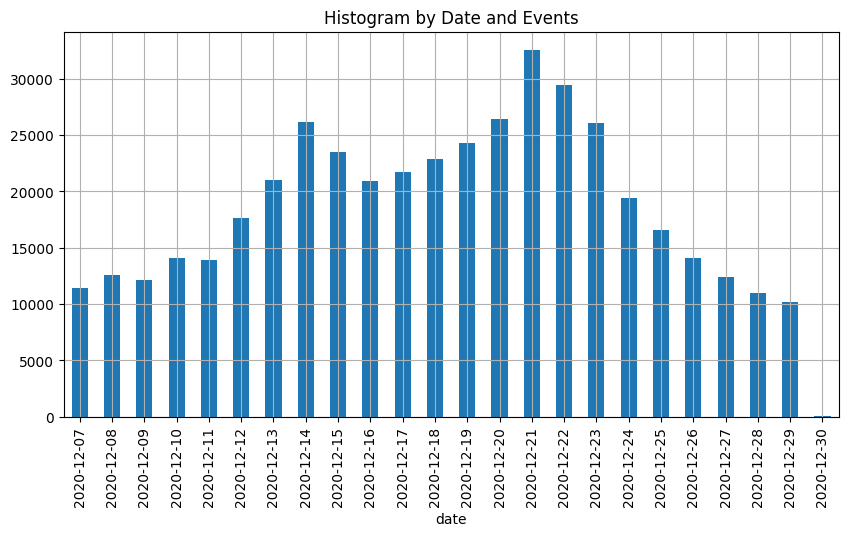

In [55]:
final_ab_events.groupby('date')['event_name'].count().plot(kind='bar', grid=True, figsize=(10,5))
plt.title('Histogram by Date and Events')

In [56]:
final_ab_events.groupby('date')['event_name'].count().describe()

count       24.000000
mean     18346.541667
std       7493.484399
min         89.000000
25%      12515.250000
50%      18516.500000
75%      23670.000000
max      32559.000000
Name: event_name, dtype: float64

On average, 18 516 events occur per day.

* 25% of days recorded a below-average number of events: from 10 000 to 12 515. For example, the periods December 29-27 and December 7-December 9. These are the start and end of the test. December 30 recorded the minimum number of events, with virtually no events.

* 25% of days recorded a number of events: from 12 515 to 18 516.
For example, the period from December 25-26 inclusive and December 12.

* 25% of days recorded a number of events: from 18 516 to 23 670.
For example, the days: December 13, 16, 17, 18, and 24.

* 25% of days recorded a number of events: from 23 670 to 32 559.
For example, the periods: December 14-15, December 19-23.

* The peak day, with the maximum number of events, was December 21.
December 22 was in second place.

**2.5. Data Nuances to Consider Before Starting A/B Testing**<a class="anchor" id="2-5-bullet"></a>

    It's necessary to check whether any marketing events or holidays that impact user/buyer behavior occurred during the testing period. To do this, you need to check the "ab_project_marketing_events" table.

In [57]:
project_marketing_events.head(15)

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11


    As we previously determined, event data was collected from 2020-12-07 to 2020-12-30.

    The "Christmas & New Year Promo" marketing event ran during the last five days of the period, starting from 2020-12-25. Region: EU, N.America. The overlap of the A/B test with marketing activities is incorrect and may affect the A/B test results.

    On the last day of the period, the CIS New Year Gift Lottery marketing event began, starting from 2020-12-30. Since this is the CIS region, this event does not affect the A/B test results.

**2.6. Users from Two Experimental Groups in the Recommender_System_Test**<a class="anchor" id="2-6-bullet"></a>


In [58]:
final_ab_participants.query('ab_test == "recommender_system_test"').groupby('group')['user_id'].nunique()

group
A    3824
B    2877
Name: user_id, dtype: int64

    The "recommender_system_test" test includes users from both groups.

    Group B has 947 fewer users than Group A, representing 24.77%.

### Step 3. Evaluate the A/B Testing Results<a class="anchor" id="3-bullet"></a>

To evaluate the results of an A/B test, you need to create a pivot table that includes:

* only new users from the EU region;
* only users who participated in the recommender_system_test
* information about which group the user belongs to (A/B)
* events

1. Filter the ab_new_users table by users from the EU region
2. Filter the final_ab_participants table by only users who participated in the recommender_system_test
3. Join the filtered ab_new_users, final_ab_participants, and final_ab_events tables by the user_id field

In [59]:
ab_new_users_EU = ab_new_users[ab_new_users['region'] == "EU"]
ab_new_users_EU.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
7,8942E64218C9A1ED,2020-12-07,EU,PC
9,FFCEA1179C253104,2020-12-07,EU,Android


In [60]:
ab_participants_RST = final_ab_participants[final_ab_participants['ab_test'] == "recommender_system_test"]
ab_participants_RST.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,482F14783456D21B,B,recommender_system_test


In [61]:
users_EU_test_RST = ab_new_users_EU.merge(ab_participants_RST, on='user_id', how='left') 
users_EU_test_RST.head()

,user_id,first_date,region,device,group,ab_test
0,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test
1,2E1BF1D4C37EA01F,2020-12-07,EU,PC,NaN,NaN
2,50734A22C0C63768,2020-12-07,EU,iPhone,NaN,NaN
3,8942E64218C9A1ED,2020-12-07,EU,PC,NaN,NaN
4,FFCEA1179C253104,2020-12-07,EU,Android,NaN,NaN


    The table now contains empty values: new EU users 
    who did not participate in the test. We'll remove them.

In [62]:
users_EU_test_RST.dropna()

,user_id,first_date,region,device,group,ab_test
0,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test
7,E6DE857AFBDC6102,2020-12-07,EU,PC,B,recommender_system_test
13,DD4352CDCF8C3D57,2020-12-07,EU,Android,B,recommender_system_test
16,831887FE7F2D6CBA,2020-12-07,EU,Android,A,recommender_system_test
28,4CB179C7F847320B,2020-12-07,EU,iPhone,B,recommender_system_test
...,...,...,...,...,...,...
46231,A09DFE27D4CFF8E8,2020-12-20,EU,Android,B,recommender_system_test
46238,0F7D49FC184EDCDE,2020-12-20,EU,PC,A,recommender_system_test
46249,574ACBC674BC385D,2020-12-20,EU,Mac,A,recommender_system_test
46250,0416B34D35C8C8B8,2020-12-20,EU,Android,A,recommender_system_test


In [63]:
common_table = users_EU_test_RST.merge(final_ab_events, on='user_id', how='left')
common_table.head()

,user_id,first_date,region,device,group,ab_test,event_dt,event_name,details,date
0,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test,2020-12-07 21:52:10,product_page,NaN,2020-12-07
1,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test,2020-12-07 21:52:07,login,NaN,2020-12-07
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC,NaN,NaN,2020-12-07 09:05:47,product_cart,NaN,2020-12-07
3,2E1BF1D4C37EA01F,2020-12-07,EU,PC,NaN,NaN,2020-12-10 04:13:53,product_cart,NaN,2020-12-10
4,2E1BF1D4C37EA01F,2020-12-07,EU,PC,NaN,NaN,2020-12-12 17:54:57,product_cart,NaN,2020-12-12


In [64]:
common_table.dropna(subset = ['group', 'ab_test', 'event_dt', 'event_name', 'date'], inplace = True)
common_table.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23420 entries, 0 to 329849
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     23420 non-null  object        
 1   first_date  23420 non-null  datetime64[ns]
 2   region      23420 non-null  object        
 3   device      23420 non-null  object        
 4   group       23420 non-null  object        
 5   ab_test     23420 non-null  object        
 6   event_dt    23420 non-null  datetime64[ns]
 7   event_name  23420 non-null  object        
 8   details     3196 non-null   float64       
 9   date        23420 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 2.0+ MB


In [65]:
common_table.duplicated().sum()

0

**Let's create a table that will count the number of users who performed each event for all groups**

In [66]:
groups = common_table.pivot_table(values='user_id', index='group', columns='event_name', aggfunc='nunique')
groups

event_name,login,product_cart,product_page,purchase
group,,,,
A,2604,782,1685,833
B,877,244,493,249


### Let's check the statistical difference in proportions using the z-test

*Null hypothesis H0* - there is no significant difference between the proportions

*Alternative hypothesis H1* - there is a significant difference between the proportions

In [67]:
from scipy import stats as st
import numpy as np
import math as mth

***Conversion to product card views (product_page event)***

In [68]:
alpha = .05
successes = np.array([1685, 493])
trials = np.array([2604, 877])
p1 = successes[0]/trials[0]
p2 = successes[1]/trials[1]
p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])
difference = p1 - p2
z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))
distr = st.norm(0, 1)
p_value = (1 - distr.cdf(abs(z_value))) * 2
print('p-value: ', p_value)
if (p_value < alpha):
    print("We reject the null hypothesis: there is a significant difference between the proportions")
else:
    print("The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.")

p-value:  6.942739359416805e-06
We reject the null hypothesis: there is a significant difference between the proportions


    There is a significant difference in the conversion rate for the product_page event in the two groups.

    Group A has a higher conversion rate than Group B.

***Purchase conversion***

In [69]:
alpha = .05
successes = np.array([833, 249])
trials = np.array([2604, 877])
p1 = successes[0]/trials[0]
p2 = successes[1]/trials[1]
p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])
difference = p1 - p2
z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))
distr = st.norm(0, 1)
p_value = (1 - distr.cdf(abs(z_value))) * 2
print('p-value: ', p_value)
if (p_value < alpha):
    print("We reject the null hypothesis: there is a significant difference between the proportions")
else:
    print("The null hypothesis could not be rejected; there is no reason to believe that the proportions are different")

p-value:  0.04652482738393027
We reject the null hypothesis: there is a significant difference between the proportions


    There is a significant difference in the purchase event conversion rate between the two groups.

    Group A has a higher conversion rate than Group B.

***Conversion to adding products to cart (product_card event)***

In [70]:
alpha = .05
successes = np.array([782, 244])
trials = np.array([2604, 877])
p1 = successes[0]/trials[0]
p2 = successes[1]/trials[1]
p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])
difference = p1 - p2
z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))
distr = st.norm(0, 1)
p_value = (1 - distr.cdf(abs(z_value))) * 2
print('p-value: ', p_value)
if (p_value < alpha):
    print("We reject the null hypothesis: there is a significant difference between the proportions")
else:
    print("The null hypothesis could not be rejected; there is no reason to believe that the proportions are different")

p-value:  0.21469192029582396
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different


    There is no significant difference in the conversion rate of the product_card event between the two groups.

### Step 4. Conclusions from the Exploratory Data Analysis Stage and the Evaluation of the A/B Testing Results<a class="anchor" id="4-bullet"></a>

1. The "Christmas & New Year Promo" marketing event took place in the last 5 days of the period
from 2020-12-25. Region - EU, N.America. The overlap of the A/B test with marketing activities
is incorrect; this could have affected the A/B test results.

2. A total of 4 events in the funnel, sorted by frequency:

* login - 58 697 users
* product_page - 38 929 users
* purchase - 19 569 users
* product_cart - 19 284 users

Some users place an order without going through the "add to cart" step.
This is because there are fewer transactions at this step than at the "order" step. This occurs in the dataset
as a whole, in group A, and in group B.

The largest number of users is lost at the third stage. Only 50% of users make a purchase after viewing the product page. At the second stage, 36% of users are lost. After registration, 66% of users
view product pages.
Between adding a product to cart and placing an order, the conversion rate is 99%.

3. Users experience a different number of events:

* 25% of users experience 4 events.
* 50% of users experience up to 6 events.
* 75% of users experience up to 9 events.
* Outliers range from 16 to 36 events per user.
* The maximum outlier is 36 events per user.
    
    
4. 776 users were assigned to both Group A and Group B, but in different tests (either in the recommender_system_test test from Group A or the interface_eu_test test from Group B).

There were no users who participated in the same test in both groups.

5. The number of events is not evenly distributed across days.

On average, 18 516 events occur per day.

* 25% of days recorded a below-average number of events: from 10 000 to 12 515. For example, the periods December 29-27 and December 7-December 9. These are the beginning and end of the test. December 30 recorded the lowest number of events, with virtually no events.

* 25% of days recorded a number of events: from 12 515 to 18 516. For example, the period from December 25-26 inclusive and December 12.

* 25% of days had between 18 516 and 23 670 events. For example, the following days: December 13, 16, 17, 18, and 24

* 25% of days had between 23 670 and 32 559 events. For example, the following periods: December 14-15 and December 19-23.

The peak day with the highest number of events was December 21. December 22 was second.

6. Evaluation of A/B testing results showed:

* There is a significant difference between the shares of the product_page event conversion in the two groups. Group A has a higher conversion rate than Group B.

* There is a significant difference between the shares of the purchase event conversion in the two groups. Group A has a higher conversion rate than Group B.

* There is no significant difference between the shares of the product_card event conversion in the two groups.

Thus, the expected result was not confirmed. Test group B did not show better conversion compared to control group A.


